# 02 — Validate the method, then predict

Notebook 01 built the factor the way we believe the original was made
(equal-weighted average of six signed 21d EWM z-scores). This notebook:

- **A.** digitizes the target chart into a benchmark trace (checker only)
- **B.** scores our construction against it and picks the best METHOD
  variant (never the numbers — see the anti-overfitting note below)
- **C.** pulls an event calendar from Bloomberg (FOMC, CPI, payrolls)
  and auto-annotates the chart
- **D.** decomposes the latest big move into component contributions
- **E.** predicts forward with AR(1) — **on the equal-weight factor**
- **F.** `live_refresh()`: one call to pull to today and extrapolate

Notebook 03 then fits weights to the chart itself (with guard rails)
and compares its prediction against this notebook's.

**Anti-overfitting rule used here:** the benchmark is only a scorecard.
We choose between ~12 equally-defensible method readings (halflife/span/
com × level/change × WTI/Brent), all with equal weights. A 12-option
menu cannot memorize a chart.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bbg
import factor_lib as fl

if bbg.MOCK_MODE:
    print("MOCK MODE - scores vs the real benchmark are meaningless here.")

factor = pd.read_csv("factor.csv", index_col=0, parse_dates=True).iloc[:, 0]

MOCK MODE - scores vs the real benchmark are meaningless here.


### Part A — the benchmark trace (digitized from the chart image)

(date, value) anchor points read off the image by eye, interpolated to
business days. Approximate on purpose — refine any anchor with the image
open next to this cell.

In [2]:
ANCHORS = [
    ("2025-01-02", 0.25), ("2025-01-08", 0.60), ("2025-01-14", -0.10),
    ("2025-01-21", 0.35), ("2025-01-28", -0.50), ("2025-02-04", 0.30),
    ("2025-02-11", -0.70), ("2025-02-18", -1.90), ("2025-02-25", -1.20),
    ("2025-03-04", -0.30), ("2025-03-11", 0.40), ("2025-03-18", -0.80),
    ("2025-03-25", -0.20), ("2025-04-01", 0.50), ("2025-04-08", 1.15),
    ("2025-04-15", 2.05), ("2025-04-22", 1.50), ("2025-04-29", 0.70),
    ("2025-05-06", 1.30), ("2025-05-13", 0.50), ("2025-05-20", 1.00),
    ("2025-05-27", 0.30), ("2025-06-03", 0.80), ("2025-06-10", 0.20),
    ("2025-06-17", 0.60), ("2025-06-24", -0.20), ("2025-07-01", 0.50),
    ("2025-07-08", -0.90), ("2025-07-15", 0.30), ("2025-07-22", 0.70),
    ("2025-07-29", 0.10), ("2025-08-05", 0.60), ("2025-08-12", -0.50),
    ("2025-08-19", 1.70), ("2025-08-26", 1.50), ("2025-09-02", 0.90),
    ("2025-09-09", 0.40), ("2025-09-16", 0.80), ("2025-09-23", -0.10),
    ("2025-09-30", 0.30), ("2025-10-07", -0.70), ("2025-10-14", -1.60),
    ("2025-10-21", -0.90), ("2025-10-28", -0.30), ("2025-11-04", 0.50),
    ("2025-11-11", -0.40), ("2025-11-18", -1.70), ("2025-11-25", -0.80),
    ("2025-12-02", 0.40), ("2025-12-09", 1.10), ("2025-12-16", 1.80),
    ("2025-12-23", 1.60), ("2025-12-30", 1.00), ("2026-01-06", 1.85),
    ("2026-01-13", 1.30), ("2026-01-20", 1.60), ("2026-01-27", 0.60),
    ("2026-02-03", 0.40), ("2026-02-10", 0.90), ("2026-02-17", -0.20),
    ("2026-02-24", 0.50), ("2026-03-03", -0.90), ("2026-03-10", -1.65),
    ("2026-03-17", -0.40), ("2026-03-24", 0.20), ("2026-03-31", -0.60),
    ("2026-04-07", 0.60), ("2026-04-14", 1.20), ("2026-04-21", 0.40),
    ("2026-04-28", 0.90), ("2026-05-05", -0.60), ("2026-05-12", 0.20),
    ("2026-05-19", 1.20), ("2026-05-26", 0.80), ("2026-06-02", 0.50),
    ("2026-06-09", 1.00), ("2026-06-16", 0.90), ("2026-06-18", 1.60),
    ("2026-06-22", 2.05), ("2026-06-24", 1.70), ("2026-06-26", 1.95),
    ("2026-06-30", 1.60), ("2026-07-02", 0.90), ("2026-07-06", 0.40),
    ("2026-07-08", -0.05),
]

anchor_series = pd.Series({pd.Timestamp(d): v for d, v in ANCHORS})
bdays = pd.bdate_range(anchor_series.index[0], anchor_series.index[-1])
benchmark = anchor_series.reindex(bdays).interpolate(method="time")
benchmark.name = "benchmark"
benchmark.to_frame().to_csv("benchmark.csv")
print(f"Benchmark: {len(benchmark)} days, saved benchmark.csv")

Benchmark: 395 days, saved benchmark.csv


### Part B — score method variants, adopt the best

Correlation asks "does it wiggle at the right times?", RMSE asks "is it
at the right level?".

In [3]:
def score_against_benchmark(candidate):
    both = pd.DataFrame({"cand": candidate, "bench": benchmark}).dropna()
    corr = both["cand"].corr(both["bench"])
    rmse = np.sqrt(((both["cand"] - both["bench"]) ** 2).mean())
    return corr, rmse


raw = bbg.bdh(fl.TICKERS, "PX_LAST",
              pd.Timestamp(2025, 1, 1).date()).ffill().dropna()

results = []
for ewm_kind in ["halflife", "span", "com"]:
    for z_on in ["level", "change"]:
        for oil in ["CL1 Comdty", "CO1 Comdty"]:
            signed_z = fl.build_signed_zscores(raw, ewm_kind=ewm_kind,
                                               z_on=z_on, oil=oil)
            corr, rmse = score_against_benchmark(fl.build_factor(signed_z))
            results.append({"ewm_kind": ewm_kind, "z_on": z_on,
                            "oil": oil.split()[0], "corr": round(corr, 3),
                            "rmse": round(rmse, 3)})

table = pd.DataFrame(results).sort_values("corr", ascending=False)
print(table.to_string(index=False))

best = table.iloc[0]
CHOSEN = {"ewm_kind": best["ewm_kind"], "z_on": best["z_on"],
          "oil": best["oil"] + " Comdty"}
print(f"\nAdopted method: {CHOSEN}")

signed_z_best = fl.build_signed_zscores(raw, ewm_kind=CHOSEN["ewm_kind"],
                                        z_on=CHOSEN["z_on"], oil=CHOSEN["oil"])
factor_best = fl.build_factor(signed_z_best)

with open("chosen_method.json", "w") as f:
    json.dump(CHOSEN, f, indent=2)
signed_z_best.to_csv("signed_zscores.csv")
factor_best.to_frame("factor").to_csv("factor.csv")

ewm_kind   z_on oil   corr  rmse
halflife  level CO1  0.582 0.819
halflife  level CL1  0.574 0.829
     com  level CO1  0.555 0.839
     com  level CL1  0.545 0.849
    span  level CO1  0.432 0.912
    span  level CL1  0.419 0.922
halflife change CO1 -0.022 1.099
halflife change CL1 -0.027 1.108
     com change CO1 -0.032 1.098
     com change CL1 -0.038 1.106
    span change CO1 -0.051 1.087
    span change CL1 -0.057 1.095

Adopted method: {'ewm_kind': 'halflife', 'z_on': 'level', 'oil': 'CO1 Comdty'}


**Reading the table on real data:** adopt a clear winner (corr gap
> ~0.05); if several tie, take the simplest — ties mean the choice
doesn't matter. Don't chase the second decimal: the benchmark itself is
digitized by eye, so beyond corr ≈ 0.9 you'd be fitting reading error.

### Part C — event calendar from the Bloomberg API

Event dates come from Bloomberg's economic calendar tickers, not a
hardcoded list:

- `FDTR Index` = the Fed rate decision -> its release dates ARE the
  FOMC announcement days
- `CPI YOY Index`, `NFP TCH Index` = CPI and payrolls days

`bds(ticker, "ECO_FUTURE_RELEASE_DATE_LIST")` returns the UPCOMING
dates. Past dates: Bloomberg's calendar page (`ECO <GO>`) can export
history; we keep a small editable list for past FOMC days and let the
API fill the future. Big factor-move days additionally get auto-labeled
with the component that drove them (a data-generated headline). If a
`headlines.csv` (columns: date,headline) exists, its text wins.

In [4]:
import os

PAST_FOMC = ["2025-01-29", "2025-03-19", "2025-05-07", "2025-06-18",
             "2025-07-30", "2025-09-17", "2025-10-29", "2025-12-10",
             "2026-01-28", "2026-03-18", "2026-04-29", "2026-06-17"]

CALENDAR_TICKERS = {"FDTR Index": "FOMC", "CPI YOY Index": "CPI",
                    "NFP TCH Index": "NFP"}

events = [{"date": pd.Timestamp(d), "label": "FOMC"} for d in PAST_FOMC]
for ticker, label in CALENDAR_TICKERS.items():
    try:
        for d in bbg.bds(ticker, "ECO_FUTURE_RELEASE_DATE_LIST"):
            events.append({"date": pd.Timestamp(str(d)[:10]), "label": label})
    except Exception as e:
        print(f"calendar pull failed for {ticker} (non-fatal): {e}")

events = pd.DataFrame(events).drop_duplicates().sort_values("date")
events.to_csv("events.csv", index=False)
print(events.tail(8).to_string(index=False))


def load_headlines():
    if not os.path.exists("headlines.csv"):
        return {}
    df = pd.read_csv("headlines.csv", parse_dates=["date"])
    return {row["date"].normalize(): str(row["headline"])[:60]
            for _, row in df.iterrows()}


def biggest_move_days(factor_series, signed_z, n=6):
    """Largest 1-day factor moves + the component that drove each."""
    changes = factor_series.diff().dropna()
    z_changes = signed_z.diff()
    top = changes.abs().sort_values(ascending=False).head(n).index
    rows = []
    for date in sorted(top):
        driver = z_changes.loc[date].abs().idxmax()
        rows.append({"date": date, "move": round(changes[date], 2),
                     "driver": driver,
                     "driver_move": round(z_changes.loc[date, driver], 2)})
    return pd.DataFrame(rows)


def annotate_events(ax, factor_series, signed_z, n=6):
    """Event lines + driver labels, kept INSIDE the axes (no clipping)."""
    headlines = load_headlines()
    lo, hi = ax.get_ylim()

    for _, ev in events.iterrows():
        d = ev["date"]
        if factor_series.index[0] <= d <= factor_series.index[-1]:
            color = "darkred" if ev["label"] == "FOMC" else "grey"
            ax.axvline(d, color=color, linestyle=":", alpha=0.45)
            ax.text(d, hi - 0.05, ev["label"], color=color, fontsize=6,
                    rotation=90, ha="right", va="top", clip_on=True)

    for _, ev in biggest_move_days(factor_series, signed_z, n).iterrows():
        label = headlines.get(ev["date"].normalize(),
                              f"{ev['driver']} {ev['driver_move']:+.1f}")
        y = float(factor_series[ev["date"]])
        y = max(lo + 0.3, min(hi - 0.3, y))
        dy = -26 if y > 0 else 26
        ax.annotate(label, xy=(ev["date"], y),
                    xytext=(0, dy), textcoords="offset points",
                    fontsize=7, ha="center", clip_on=True,
                    arrowprops=dict(arrowstyle="-", color="grey", alpha=0.6))


print("\nBiggest factor-move days:")
print(biggest_move_days(factor_best, signed_z_best).to_string(index=False))

      date label
2026-09-04   NFP
2026-09-11   CPI
2026-09-16  FOMC
2026-10-02   NFP
2026-10-13   CPI
2026-10-28  FOMC
2026-11-06   NFP
2026-12-09  FOMC

Biggest factor-move days:
      date  move       driver  driver_move
2025-01-15 -1.88 infl_swap_5y        -3.52
2025-01-16  1.19 infl_swap_5y         2.62
2025-08-12  1.29    yield_30y         2.34
2026-03-03  1.52    yield_30y         2.48
2026-03-19  1.34         gold         2.00
2026-04-01  1.24         gold         1.95


### The overlay, with events and readable axes

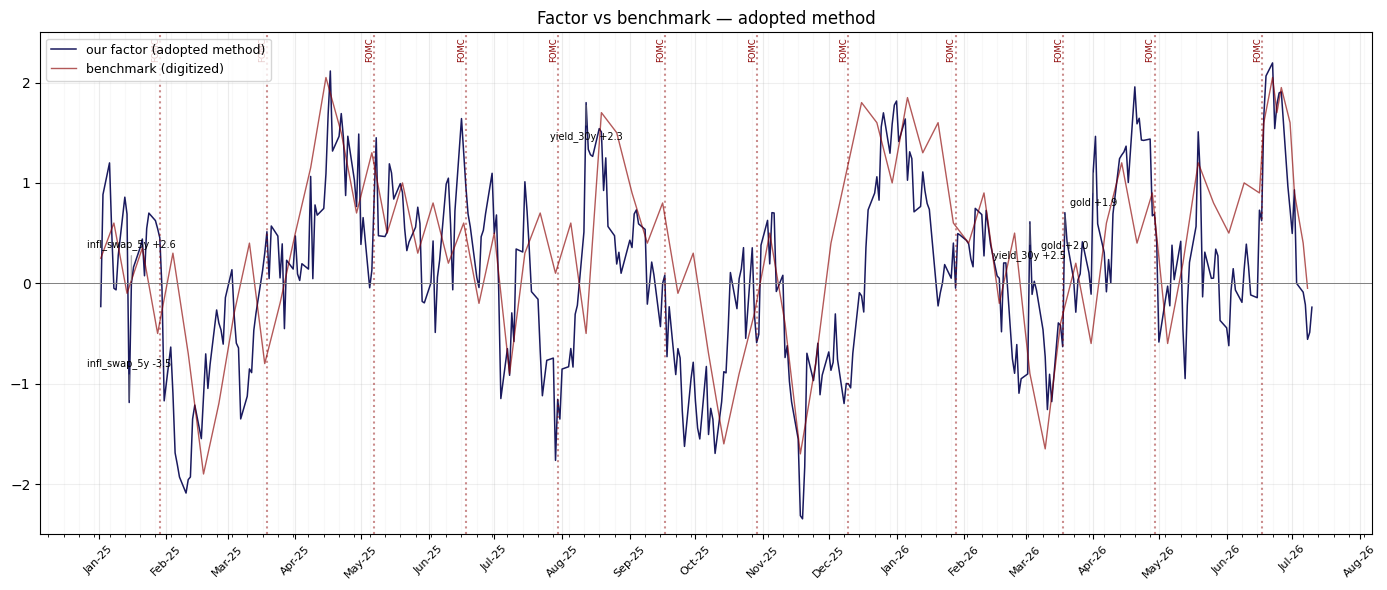

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(factor_best.index, factor_best.values, color="#1a1a5e",
        linewidth=1.1, label="our factor (adopted method)")
ax.plot(benchmark.index, benchmark.values, color="darkred", linewidth=1.0,
        alpha=0.65, label="benchmark (digitized)")
ax.axhline(0, color="grey", linewidth=0.7)
ax.set_ylim(-2.5, 2.5)
annotate_events(ax, factor_best, signed_z_best)
fl.format_time_axis(ax)
ax.set_title("Factor vs benchmark — adopted method")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("factor_vs_benchmark_best.png", dpi=120)
plt.show()

### Part D — decomposition: who drove the latest big move?

Equal weights mean any move decomposes exactly:
`factor_change = sum of (signed_z_change / 6)`. In mock mode the planted
ground-truth shares are shown alongside as a code check.

In [6]:
fomc_date = pd.Timestamp(2026, 6, 17)
after = factor_best[factor_best.index >= fomc_date]
peak_date = after.idxmax()

contribution = (signed_z_best.iloc[-1] - signed_z_best.loc[peak_date]) / 6.0
share = contribution / contribution.sum()

planted = {}
if bbg.MOCK_MODE:
    key_map = {"yield_30y": "30y", "dxy": "dxy", "infl_swap_5y": "swap",
               "fomc_hike": "fomc", "oil": "oil", "gold": "gold"}
    planted = {n_: bbg._UNWIND_SHARES[k] for n_, k in key_map.items()}

print(f"Move from peak ({peak_date.date()}) to latest: {contribution.sum():+.2f}\n")
print(f"{'component':<14}{'share':>8}" + ("{:>10}".format("planted") if planted else ""))
for name in share.sort_values().index:
    line = f"{name:<14}{share[name]:>7.0%}"
    if planted:
        line += f"{planted[name]:>9.0%}"
    print(line)

Move from peak (2026-06-22) to latest: -2.43

component        share   planted
fomc_hike         13%      16%
gold              14%       3%
oil               16%      16%
dxy               17%      17%
infl_swap_5y      20%      17%
yield_30y         21%      31%


### Part E — predict with AR(1) (on the EQUAL-WEIGHT factor)

To be explicit: this forecast is based on the factor built with the
adopted METHOD and **equal weights** — the principled construction.
Notebook 03 produces the chart-fitted alternative and compares.

AR(1): `tomorrow = a + b*today + noise`; shock half-life =
`ln(0.5)/ln(b)`; k-step uncertainty = `noise_std*sqrt((1-b^2k)/(1-b^2))`.

In [7]:
def ar1_forecast(series, horizon):
    """Fit AR(1) and forecast. Returns (future_dates, path, spread, info)."""
    y = series.dropna()
    b, a = np.polyfit(y.values[:-1], y.values[1:], 1)
    noise_std = (y.values[1:] - (a + b * y.values[:-1])).std()

    path, spread = [], []
    value = y.iloc[-1]
    for k in range(1, horizon + 1):
        value = a + b * value
        path.append(value)
        spread.append(noise_std * np.sqrt((1 - b ** (2 * k)) / (1 - b ** 2)))

    future_dates = pd.bdate_range(y.index[-1], periods=horizon + 1)[1:]
    info = {"a": a, "b": b, "noise_std": noise_std,
            "half_life": np.log(0.5) / np.log(b),
            "long_run_mean": a / (1 - b)}
    return future_dates, np.array(path), np.array(spread), info


HORIZON = 63
fdates, path, spread, info = ar1_forecast(factor_best, HORIZON)

pd.DataFrame({"date": fdates, "path": path, "spread": spread}) \
  .to_csv("forecast_equal.csv", index=False)

print(f"AR(1): tomorrow = {info['a']:+.4f} + {info['b']:.4f} * today")
print(f"Shock half-life : {info['half_life']:.1f} business days")
print(f"Forecast in {HORIZON} days: {path[-1]:+.2f}")
print("Saved forecast_equal.csv (notebook 03 compares against it)")

AR(1): tomorrow = +0.0156 + 0.8545 * today
Shock half-life : 4.4 business days
Forecast in 63 days: +0.11
Saved forecast_equal.csv (notebook 03 compares against it)


### Part F — the live update call

One function = the whole pipeline to *today*: fresh Bloomberg pull,
rebuild with the adopted method, annotate events, extrapolate forward.

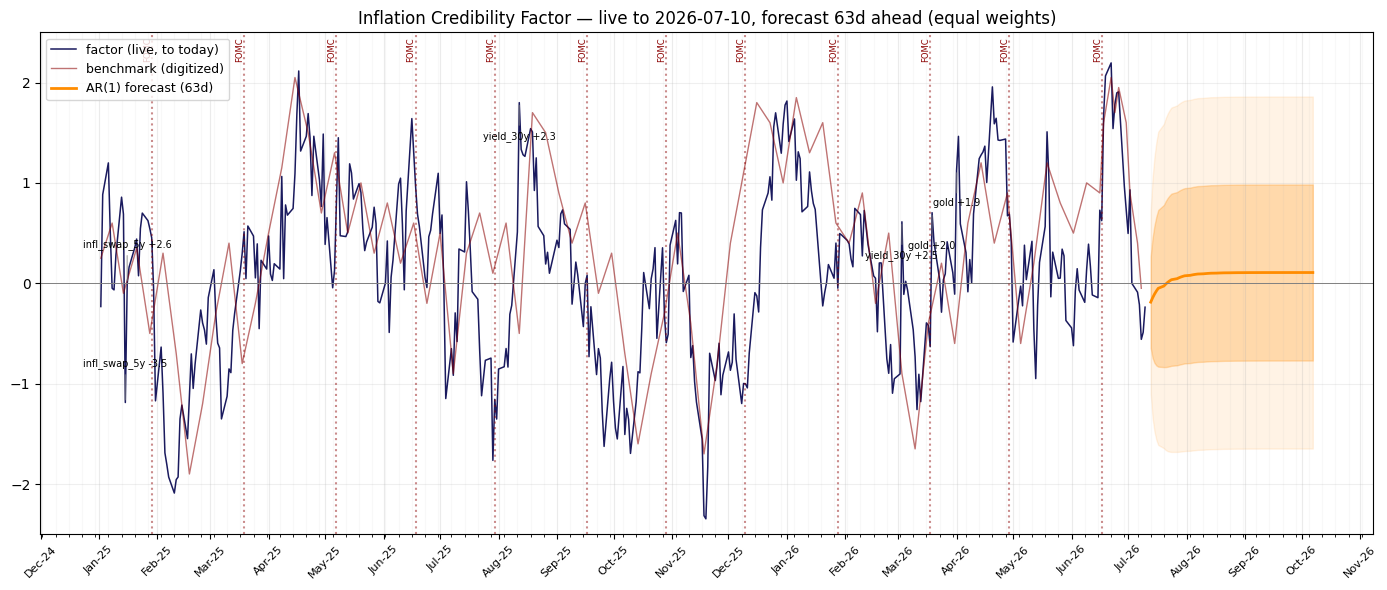

As of 2026-07-10: factor = -0.24
Forecast 63d ahead : +0.11 (reverting toward +0.11, half-life 4.4d)


In [8]:
def live_refresh(horizon=63, annotate=True):
    with open("chosen_method.json") as f:
        method = json.load(f)

    raw = bbg.bdh(fl.TICKERS, "PX_LAST",
                  pd.Timestamp(2025, 1, 1).date()).ffill().dropna()
    signed_z = fl.build_signed_zscores(raw, ewm_kind=method["ewm_kind"],
                                       z_on=method["z_on"], oil=method["oil"])
    live = fl.build_factor(signed_z)

    fdates, path, spread, info = ar1_forecast(live, horizon)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(live.index, live.values, color="#1a1a5e", linewidth=1.1,
            label="factor (live, to today)")
    ax.plot(benchmark.index, benchmark.values, color="darkred",
            linewidth=1.0, alpha=0.55, label="benchmark (digitized)")
    ax.plot(fdates, path, color="darkorange", linewidth=2,
            label=f"AR(1) forecast ({horizon}d)")
    ax.fill_between(fdates, path - spread, path + spread,
                    color="darkorange", alpha=0.25)
    ax.fill_between(fdates, path - 2 * spread, path + 2 * spread,
                    color="darkorange", alpha=0.10)
    ax.axhline(0, color="grey", linewidth=0.7)
    ax.set_ylim(-2.5, 2.5)
    if annotate:
        annotate_events(ax, live, signed_z)
    fl.format_time_axis(ax)
    ax.set_title(f"Inflation Credibility Factor — live to "
                 f"{live.index[-1].date()}, forecast {horizon}d ahead "
                 f"(equal weights)")
    ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.savefig("factor_live.png", dpi=120)
    plt.show()

    print(f"As of {live.index[-1].date()}: factor = {live.iloc[-1]:+.2f}")
    print(f"Forecast {horizon}d ahead : {path[-1]:+.2f} "
          f"(reverting toward {info['long_run_mean']:+.2f}, "
          f"half-life {info['half_life']:.1f}d)")
    return live


live_factor = live_refresh()